In [1]:
import pandas as pd
import os
import numpy as np

In [2]:
base = os.path.join(os.getcwd(),'..')

In [3]:
inDir = os.path.join(base,'stats','CASA Yield')
outDir = os.path.join(base,'compiled values')

In [4]:
def get_df(fn,year):
    df = pd.read_csv(fn)
    df.drop(columns=['system:index', 'FID', 'FID_1', 'Flowing_St', 'Program', 'State_Code','.geo'],inplace=True)
    df.rename(columns={'mean':'RS_yield'},inplace=True)
    df['RS_yield'] = df['RS_yield']/10**8
    df['year'] = year
    return df

In [5]:
df_yield = pd.DataFrame()
for r,d,f in os.walk(inDir):
    for fl in f:
        year = int(fl.split('_')[-1].split('.')[0])
        fn = os.path.join(r,fl)
        df_yield = pd.concat([df_yield,get_df(fn,year)],axis=0)

In [6]:
# df_yield.to_excel(os.path.join(outDir,'CASA_yield.xlsx'))

In [7]:
import seaborn as sns

In [9]:
df_yield

,State_Name,RS_yield,year
0,ALABAMA,7.569305,2010
1,ARIZONA,0.732591,2010
2,ARKANSAS,4.892758,2010
3,COLORADO,2.015872,2010
4,CONNECTICUT,6.118036,2010
...,...,...,...
46,OHIO,5.944543,2019
47,SOUTH DAKOTA,5.422180,2019
48,TENNESSEE,8.148629,2019
49,VERMONT,5.887127,2019


<Axes: xlabel='year', ylabel='RS_yield'>

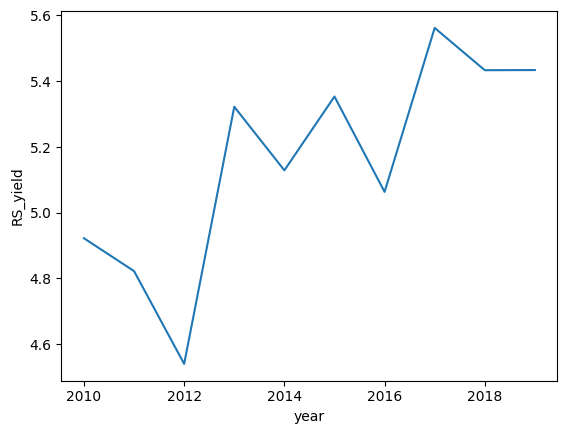

In [11]:
sns.lineplot(data=df_yield.drop(columns=['State_Name']).groupby('year').mean(),x='year',y='RS_yield')